项目步骤
1. 数据探索	Pandas（清洗、可视化）	查看类别分布、特征分布、相关性
2. 基线模型	sklearn 分类（逻辑回归）	训练、预测、用 F1/AUC 评估
3. 处理不平衡	无监督异常检测（高斯分布）或过采样	尝试 SMOTE 或调整 class_weight
4. 改进模型	随机森林 / XGBoost	对比不同模型性能

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score

In [2]:
df=pd.read_csv('creditcard.csv')

In [3]:
print(df.shape)

(284807, 31)


In [4]:
print(df['Class'].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


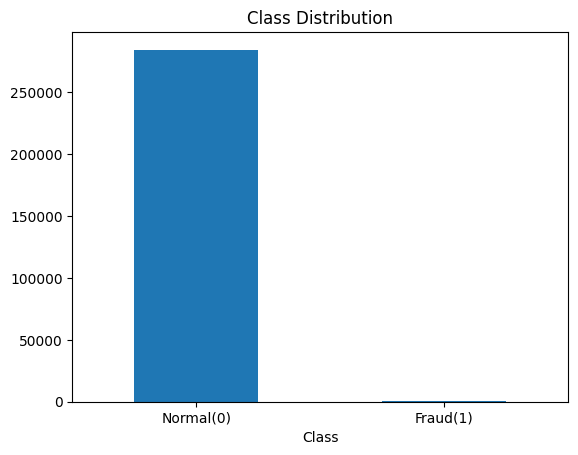

In [5]:
ax=df['Class'].value_counts().plot(kind='bar')
ax.set_xticklabels(['Normal(0)','Fraud(1)'],rotation=0)
plt.title('Class Distribution')
plt.show()

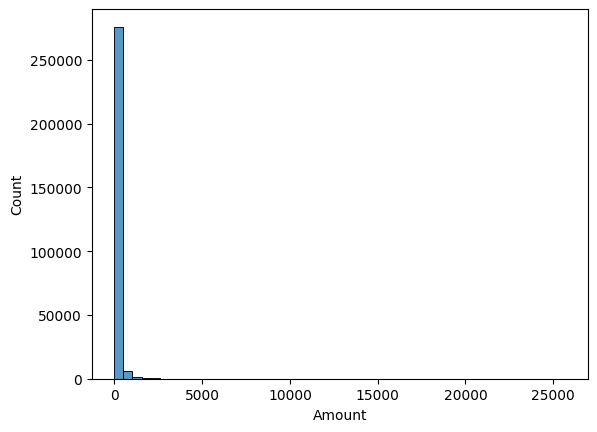

In [6]:
sns.histplot(df['Amount'],bins=50)
plt.show()

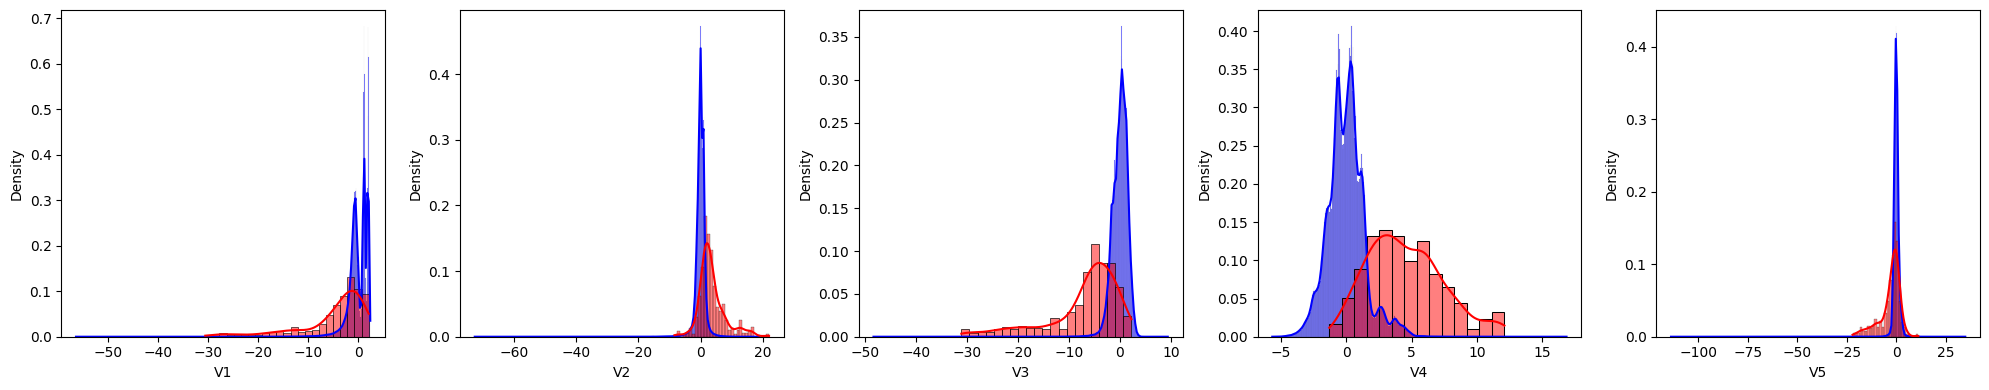

In [7]:
features_to_plot=['V1','V2','V3','V4','V5']
fig,axes=plt.subplots(1,5,figsize=(20,4))
for i ,feat in enumerate(features_to_plot):
    sns.histplot(df[df['Class']==0][feat],color='blue',label='Normal',kde=True,stat='density',ax=axes[i],alpha=0.5)
    sns.histplot(df[df['Class']==1][feat],color='red',label='Fraud',kde=True,stat='density',ax=axes[i],alpha=0.5)

plt.tight_layout()
plt.show()

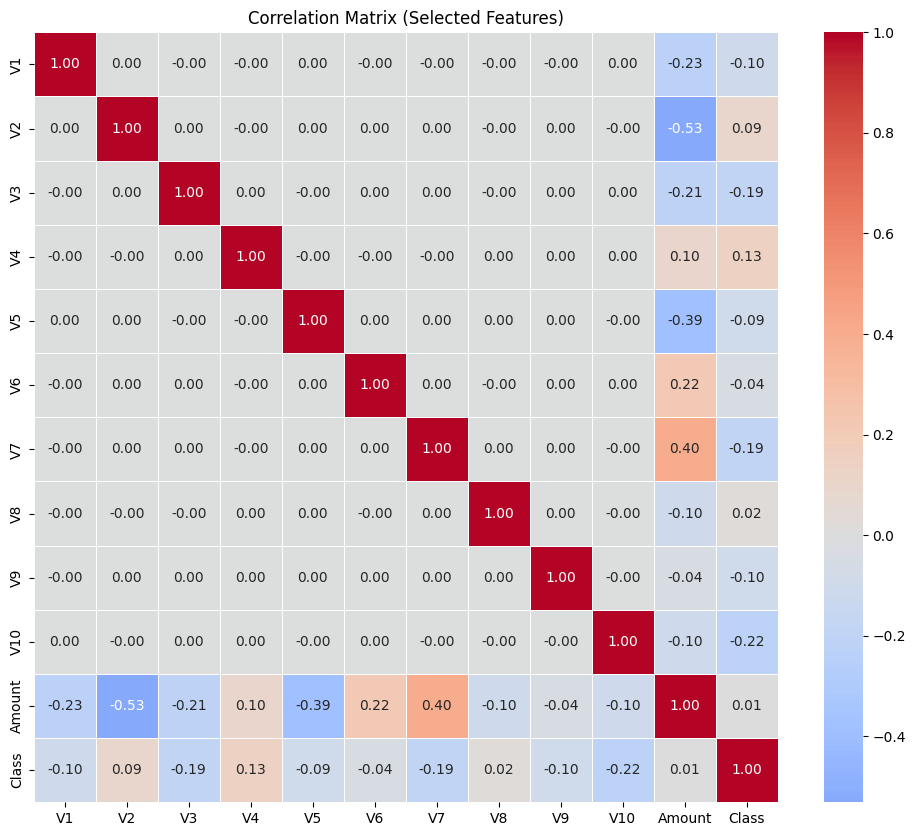

In [8]:
selected_cols=['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','Amount','Class']
corr_matrix=df[selected_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',center=0,fmt='.2f',linewidth=0.5)
plt.title('Correlation Matrix (Selected Features)')
plt.show()

In [9]:
x=df.drop('Class',axis=1)
y=df['Class']
x_sample,_,y_sample,_=train_test_split(x,y,test_size=0.9,stratify=y,random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x_sample,y_sample,test_size=0.3,stratify=y_sample,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled,y_train)
y_pred=lr.predict(x_test_scaled)

print(classification_report(y_test,y_pred,target_names=['Normal','Fraud']))
print(f'AUC:{roc_auc_score(y_test,lr.predict_proba(x_test_scaled)[:,1])}')
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      8529
       Fraud       0.90      0.60      0.72        15

    accuracy                           1.00      8544
   macro avg       0.95      0.80      0.86      8544
weighted avg       1.00      1.00      1.00      8544

AUC:0.9314651971704381
[[8528    1]
 [   6    9]]


In [10]:
from imblearn.over_sampling import SMOTE
x_full_train,x_full_test,y_full_train,y_full_test=train_test_split(x,y,test_size=0.3,stratify=y,random_state=42)
smote=SMOTE(sampling_strategy=0.1,random_state=42)#少数类数量变为多数类数量的20%
x_train_res,y_train_res=smote.fit_resample(x_full_train,y_full_train)

scaler=StandardScaler()
x_train_res_scaled=scaler.fit_transform(x_train_res)
x_test_scaled=scaler.transform(x_full_test)
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train_res_scaled,y_train_res)
probs=lr.predict_proba(x_test_scaled)[:,1]
for thresh in [0.5,0.7,0.9]:
    preds=(probs>=thresh).astype(int)
    print(f'阈值:{thresh}')
    #分类报告
    print(classification_report(y_full_test,preds, target_names=['Normal', 'Fraud']))
    #混淆矩阵
    print(confusion_matrix(y_full_test,preds))

print(f'AUC:{roc_auc_score(y_full_test,probs):.3f}')

阈值:0.5
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.54      0.83      0.66       148

    accuracy                           1.00     85443
   macro avg       0.77      0.91      0.83     85443
weighted avg       1.00      1.00      1.00     85443

[[85191   104]
 [   25   123]]
阈值:0.7
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.65      0.81      0.72       148

    accuracy                           1.00     85443
   macro avg       0.83      0.91      0.86     85443
weighted avg       1.00      1.00      1.00     85443

[[85231    64]
 [   28   120]]
阈值:0.9
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.73      0.80      0.76       148

    accuracy                           1.00     85443
   macro avg       0.86      0.90      0.88  

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 1. 数据准备

x = df[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 
        'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 
        'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']]  # 或者你选择的其它特征
y = df['Class']

# 2. 划分数据集 
x_full_train, x_full_test, y_full_train, y_full_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

# 3. 特征标准化 (注意：使用训练集统计量)
scaler = StandardScaler()
x_full_train_scaled = scaler.fit_transform(x_full_train)
x_full_test_scaled = scaler.transform(x_full_test)

# 4. 创建并训练随机森林模型
#    设置 class_weight='balanced' 是处理不平衡数据的有效手段
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(x_full_train_scaled, y_full_train)

# 5. 预测与评估
y_pred = rf_model.predict(x_full_test_scaled)
y_proba = rf_model.predict_proba(x_full_test_scaled)[:, 1]

# 使用调整出的最佳阈值
best_threshold = 0.9
y_pred_best = (y_proba >= best_threshold).astype(int)


print("【随机森林模型评估】")
print("\n分类报告 (默认阈值 0.5):")
print(classification_report(y_full_test, y_pred, target_names=['Normal', 'Fraud']))
print(f"\nAUC: {roc_auc_score(y_full_test, y_proba):.3f}")
print("\n混淆矩阵 (默认阈值 0.5):")
print(confusion_matrix(y_full_test, y_pred))


print(f"【使用最佳阈值 {best_threshold} 的评估结果】")
print(f"\n分类报告 (阈值 {best_threshold}):")
print(classification_report(y_full_test, y_pred_best, target_names=['Normal', 'Fraud']))
print("\n混淆矩阵:")
print(confusion_matrix(y_full_test, y_pred_best))

【随机森林模型评估】

分类报告 (默认阈值 0.5):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.83      0.77      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.89      0.90     85443
weighted avg       1.00      1.00      1.00     85443


AUC: 0.973

混淆矩阵 (默认阈值 0.5):
[[85272    23]
 [   34   114]]
【使用最佳阈值 0.9 的评估结果】

分类报告 (阈值 0.9):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.92      0.57      0.71       148

    accuracy                           1.00     85443
   macro avg       0.96      0.79      0.85     85443
weighted avg       1.00      1.00      1.00     85443


混淆矩阵:
[[85288     7]
 [   63    85]]
